In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [2]:
base = r"D:\JHAhn\files"

In [3]:
df = pd.read_excel(os.path.join(base, "안재혁_8641_Auto_ALPS_index_19-24_main+CTI.xlsx"))
df["PID"] = df["PID"].astype(str).str.zfill(8)
df = df.set_index("PID")
df

,PDI,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,...,LT_CTI_Assoc_Dyy,LT_CTI_Assoc_Dzz,LT_CTI-ALPS index,RT_CTI_Proj_Dxx,RT_CTI_Proj_Dyy,RT_CTI_Proj_Dzz,RT_CTI_Assoc_Dxx,RT_CTI_Assoc_Dyy,RT_CTI_Assoc_Dzz,RT_CTI-ALPS index
PID,,,,,,,,,,,,,,,,,,,,,
02459562,ADEPT54_HCS_NODDI24,NL,0,82,1,F,6.0,27,0.0,0.745723,...,0.472277,0.365113,1.109783,0.520848,0.521945,0.838614,0.467179,0.576006,0.492187,0.974257
00310282,EPT2022AD01_KDKM_NODDI32,AD,2,66,1,F,NaN,23,0.5,0.687428,...,0.183024,0.106396,1.464138,0.065613,0.067988,0.281590,0.176224,0.300066,0.182062,0.967150
00454439,EPT2022AD02_SKM_NODDI32,AD,2,74,0,M,NaN,13,2.0,0.884833,...,0.660463,0.603218,1.030054,0.572164,0.576388,0.822231,0.644952,0.752475,0.651444,0.991272
00461257,EPT2022AD03_KKS_NODDI32,SaMCI,1,74,1,F,12.0,27,0.5,0.688375,...,0.237381,0.136555,1.267073,0.154561,0.157407,0.506764,0.192443,0.356904,0.196123,0.981540
00612238,EPT2022AD05_KIJD_NODDI32,AD,2,83,1,F,NaN,24,1.0,0.687521,...,0.288539,0.223676,1.173859,0.304080,0.295770,0.657524,0.360456,0.467134,0.333783,1.055569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10412739,MWI_CN79_CYE_NODDI32,SaMCI,1,72,1,F,NaN,28,0.5,0.753935,...,0.200644,0.137980,1.401680,0.060288,0.061287,0.217723,0.152784,0.181179,0.100257,1.318971
10474812,MWI_CN80_LSR_NODDI32,MaMCI,1,78,1,F,NaN,29,0.5,0.602834,...,0.299302,0.205978,1.218601,0.095568,0.095638,0.362974,0.188456,0.319088,0.206177,0.941056
10482577,MWI_CN81_CSH_NODDI32,SaMCI,1,66,0,M,NaN,28,0.5,0.638415,...,0.252498,0.184627,1.198815,0.128332,0.117998,0.345852,0.233705,0.350583,0.250176,0.983328


In [19]:
## Mapping columns
row_to_alps_col = {
    ("ALL", "LT"): "LT_ALL_ALPS index",
    ("ALL", "RT"): "RT_ALL_ALPS index",
    ("b800", "LT"): "LT_b800_ALPS index",
    ("b800", "RT"): "RT_b800_ALPS index",
    ("b2000", "LT"): "LT_b2000_ALPS index",
    ("b2000", "RT"): "RT_b2000_ALPS index",
    ("CTI", "LT"): "LT_CTI-ALPS index",
    ("CTI", "RT"): "RT_CTI-ALPS index"
}

rows = [
    ("ALL", "DTI-ALPS (ALL)"),
    ("b800", "DTI-ALPS (b=800)"),
    ("b2000", "DTI-ALPS (b=2000)"),
    ("CTI", "CTI-ALPS (ALL)")
]
sides = [("LT", "Left"), ("RT", "Right")]

# region & component
regions = ["Hippocampus"]    # , "Insula"
comps = ["HFC", "EC", "IC"]

# Column naming : Component by 'Side' & 'Regions'
def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus' → ['HFC_LT_Hippocampus', 'EC_LT_Hippocampus', 'IC_LT_Hippocampus']
    return [f"{c}_{side}_{region}" for c in comps]

# y-Axis: column 'Group' --> 0, 1, 2
group_levels = [0, 1, 2]
group_labels = {0: "CN", 1: "MCI", 2: "AD"}

In [26]:
# Plotting
def plot_region_figure(df, region, figsize=(10, 12), dpi=120):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=figsize, dpi=dpi, sharex=True, sharey=False)
    fig.suptitle(f"{region}: ALPS indices (HFC/EC/IC overlay)", fontsize=16, y=0.985)

    # x-axis setting (이제 Group이 x축)
    for ax in axes.ravel():
        ax.set_xticks(group_levels)
        ax.set_xticklabels([group_labels[g] for g in group_levels])

    # Each cells: (row: band, col: side)
    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            ax.set_title(f"{side_title} • {row_title}", fontsize=11)

            # ALPS index cols for y-axis
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in df.columns:
                ax.text(0.5, 0.5, f"Missing ALPS:\n{alps_col}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)
                continue

            # mean(ALPS index) by groups
            y_by_group = df.groupby("Group")[alps_col].mean().reindex(group_levels)

            # Same side components: 3-Conductivity cols (HFC/EC/IC)
            cols = comp_cols(side, region)
            missing = [col for col in cols if col not in df.columns]
            if missing:
                ax.text(0.5, 0.5, "Missing comps:\n" + "\n".join(missing), ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)

            # 3 Lines for each subplot
            offsets = [-0.06, 0.0, 0.06]  # comp별 시각적 분리 (x축 스텝 내에서 약간만)
            for i, comp in enumerate(comps):
                col = f"{comp}_{side}_{region}"
                if col not in df.columns:
                    continue

                # x: Group(0,1,2) + offset / y: mean(ALPS index) by group
                x_vals = np.array(group_levels, dtype=float) + offsets[i]
                y_vals = y_by_group.values.astype(float)

                ax.plot(x_vals, y_vals, marker="o", label=comp)

            ax.set_xlabel("Group")
            ax.set_ylabel(f"{alps_col}")

            # per-subplot legend 제거 (figure-level로 통합)
            # if r == 0 and c == 1:
            #     ax.legend(title="Component", fontsize=9)

    # ── figure-level legend: 제목 바로 아래 중앙에 1개만 ──
    # 모든 축에서 핸들/라벨 수집 후 중복 제거
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)

    if handles:
        fig.legend(handles, labels,
                   loc='upper center', bbox_to_anchor=(0.5, 0.955),
                   ncol=3, title='Component', fontsize=9)

    # 레이아웃: 제목/범례 공간 확보 (tight_layout 대신 subplots_adjust)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.06,
                        hspace=0.35, wspace=0.25)

    return fig, axes

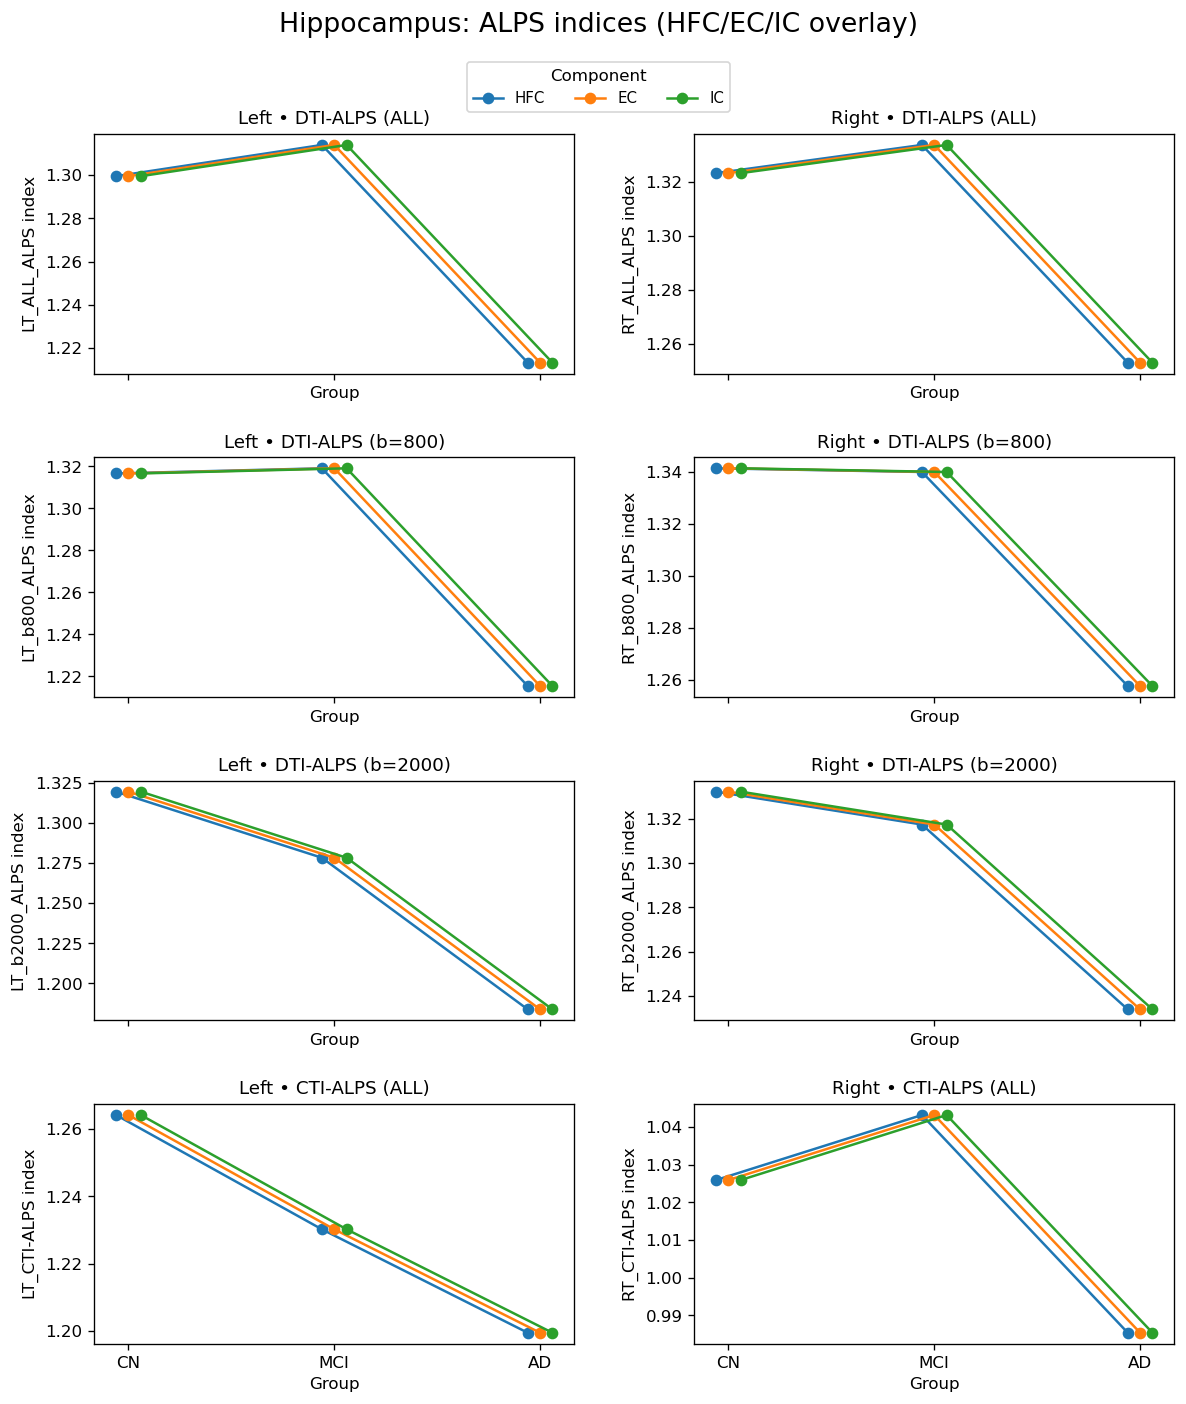

In [27]:
for reg in regions:
    plot_region_figure(df, reg)

plt.show()

In [69]:
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = df.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

group_order = ['AD', '*MCI', 'CN']  # x축 왼→오
row_labels  = ['ALL', 'b=800', 'b=2000', 'CTI']

row_to_alps_col = {
    ('ALL','LT'):   'LT_ALL_ALPS index',
    ('ALL','RT'):   'RT_ALL_ALPS index',
    ('b800','LT'):  'LT_b800_ALPS index',
    ('b800','RT'):  'RT_b800_ALPS index',
    ('b2000','LT'): 'LT_b2000_ALPS index',
    ('b2000','RT'): 'RT_b2000_ALPS index',
    ('CTI','LT'):   'LT_CTI-ALPS index',
    ('CTI','RT'):   'RT_CTI-ALPS index',
}
rows  = [('ALL','DTI-ALPS (ALL)'),
         ('b800','DTI-ALPS (b=800)'),
         ('b2000','DTI-ALPS (b=2000)'),
         ('CTI','CTI-ALPS (ALL)')]
sides = [('LT','LEFT'), ('RT','RIGHT')]

comps   = ['HFC','EC','IC']
# regions = ['Hippocampus','Insula']

def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus'
    return [f'{c}_{side}_{region}' for c in comps]


In [75]:
def plot_region_figure(dfP, region, out=None, figsize=(10, 12), dpi=120):
    """x=DDX3 그룹(AD→*MCI→CN), y=ALPS index(행·열별 선택), 각 서브플롯에 HFC/EC/IC 3라인
       - Figure-level legend (제목 아래 중앙, 한 줄)
       - 상단 행: LT / RT만 표기
       - 각 subplot 내부에 row 제목/ALPS 컬럼명 표기하지 않음
       - y라벨: 왼쪽 열에만 'ALPS index, {row_label}'
    """
    # sharex=False로 모든 subplot에 x tick 라벨 표시
    fig, axes = plt.subplots(4, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in dfP.columns:
                ax.axis('off'); continue

            # 필요한 컬럼만 취합 (ALPS + DDX3 + 컴포넌트 3개)
            needed = [alps_col, 'DDX3'] + comp_cols(side, region)
            sub = dfP[needed].copy()

            # 숫자형 변환 (ALPS와 컴포넌트들), DDX3는 카테고리 유지
            for cc in [alps_col] + comp_cols(side, region):
                sub[cc] = pd.to_numeric(sub[cc], errors='coerce')

            sub = sub.dropna(subset=[alps_col, 'DDX3'])
            if sub.empty:
                ax.axis('off'); continue

            grp    = sub.groupby('DDX3')
            y_mean = grp[alps_col].mean().reindex(group_order).dropna()
            x_pos  = np.arange(len(y_mean))  # 0,1,2

            # x축 tick/라벨: 모든 subplot에 표시
            ax.set_xticks(x_pos)
            ax.set_xticklabels(y_mean.index)
            ax.tick_params(axis='x', labelbottom=True)

            # 보조 세로선
            for xv in x_pos:
                ax.axvline(xv, linestyle='--', linewidth=1, alpha=0.35)

            # 3개 컴포넌트 라인 (요구 스펙상 y=ALPS, 동일 y 공유 → x만 오프셋)
            offsets = [-0.12, 0.0, 0.12]
            for i, comp in enumerate(comps):
                col = f'{comp}_{side}_{region}'
                if col not in sub.columns:
                    continue
                yy = y_mean.values  # y=ALPS 그룹 평균
                ax.plot(x_pos + offsets[i], yy, marker='o', label=comp)

            # 상단 행만 LT/RT 표기, 나머지는 제목 없음
            if r == 0:
                ax.set_title(side_title, fontweight='bold', fontstyle='italic', fontsize=12)
            else:
                ax.set_title("")

            # y축 라벨: 왼쪽 열만 'ALPS index, {row_label}'
            if c == 0:
                ax.set_ylabel(f'ALPS index, {row_labels[r]}')
            else:
                ax.set_ylabel('')

            # 하단 행만 x라벨(문구)
            if r == len(rows) - 1:
                ax.set_xlabel('')
            else:
                ax.set_xlabel('')

            ax.set_xlim(-0.5, len(x_pos) - 0.5)

    # 상단 통합 제목
    fig.suptitle(f'{region}: ALPS–Group plot (AD → *MCI → CN)',
                 fontsize=14, fontweight='bold', y=0.965)

    # figure-level legend (제목 아래 중앙, 한 줄)
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.945),
                   ncol=3, title='Components', fontsize=9, frameon=True)

    # 레이아웃(제목/범례 공간 확보)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.08,
                        hspace=0.35, wspace=0.25)

    if out:
        pdf_path = os.path.join(out, f'ALPS_group_means_byCond_{region}.pdf')
        fig.savefig(pdf_path)
        print(f'Saved: {pdf_path}')

    plt.show()
    plt.close(fig)

Saved: D:\JHAhn\files\ALPS_group_means_subplot_Hippocampus.pdf


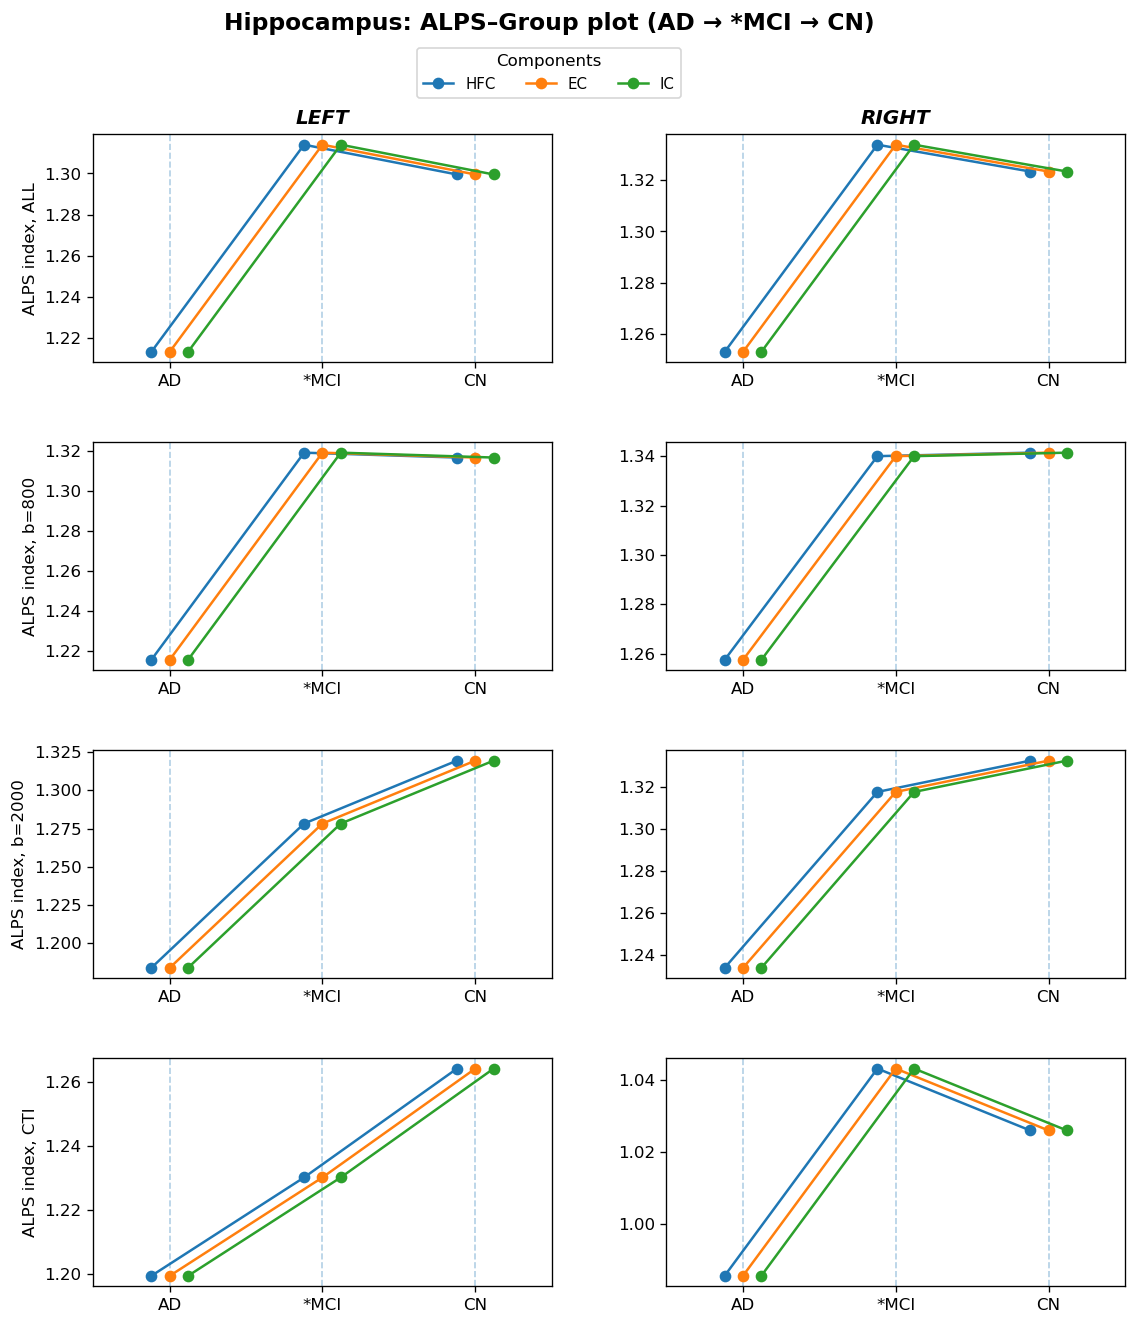

In [73]:
plot_region_figure(dfP, 'Hippocampus', out=base)

Saved: D:\JHAhn\files\ALPS_group_means_byCond_Insula.pdf


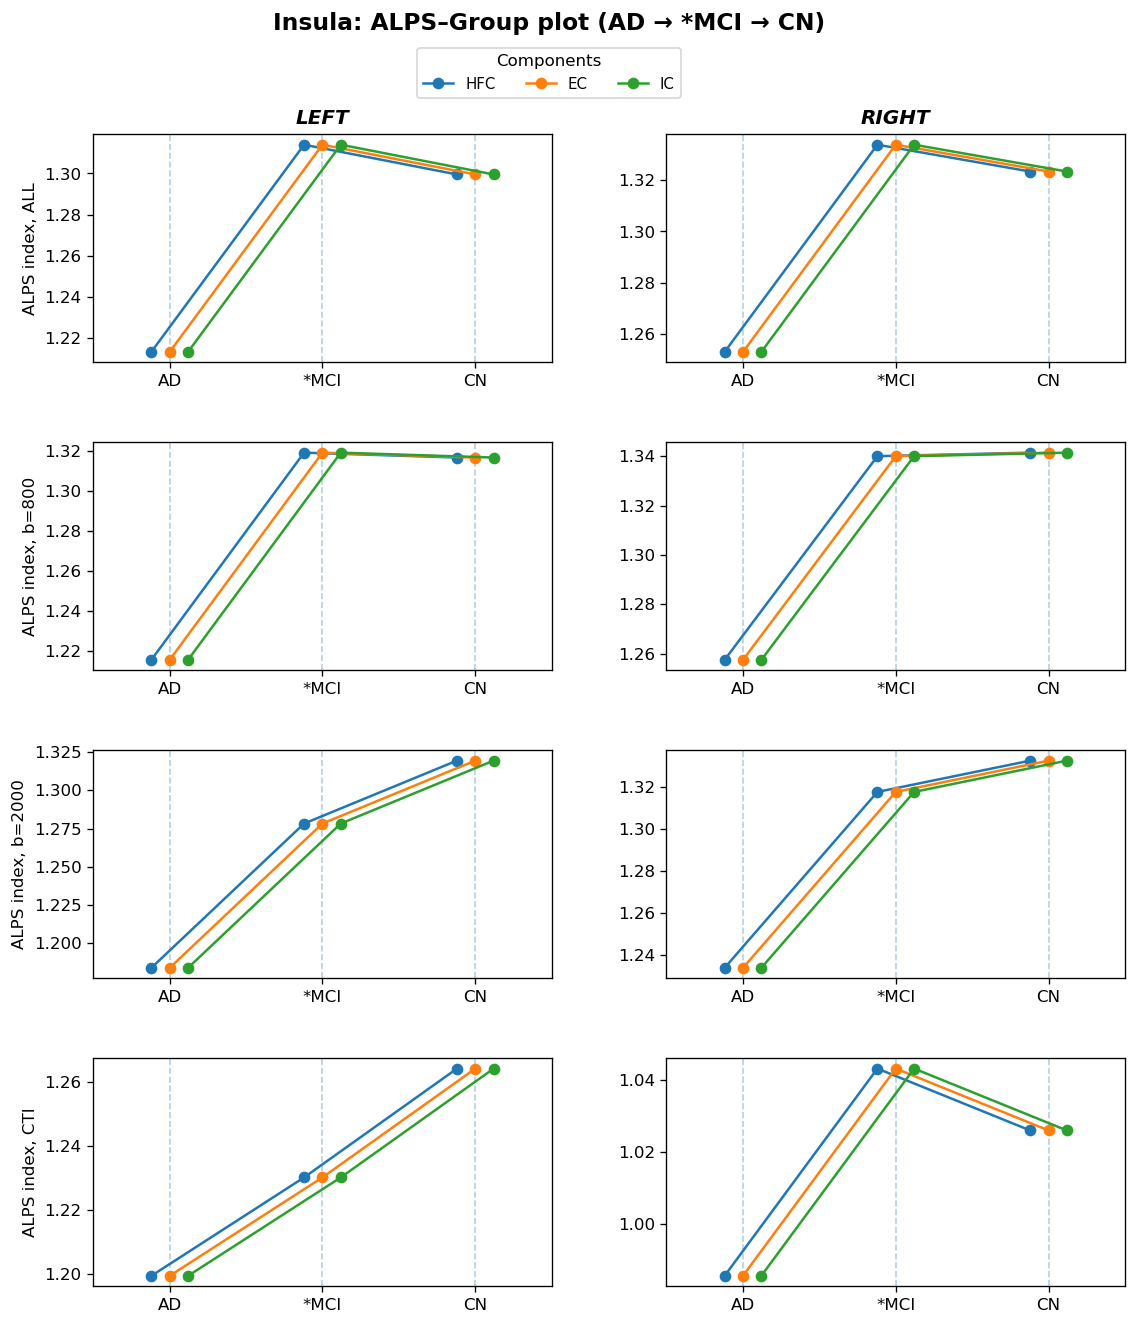

In [76]:
plot_region_figure(dfP, 'Insula', out=base)